In [3]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings

In [4]:
df = pd.read_csv("insurance.csv")
df.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
def chk_types_table(data):
    return pd.DataFrame({
        "Dtype": data.dtypes,
        "Num_Unique": data.nunique()
    }).T
chk_types_table(df)

,age,sex,bmi,children,smoker,region,charges
Dtype,int64,str,float64,int64,str,str,float64
Num_Unique,47,2,548,6,2,4,1337


In [10]:
columns_cat = df.columns
columns_cat = columns_cat.drop(['age', 'bmi', 'children', 'charges'])
columns_cat

Index(['sex', 'smoker', 'region'], dtype='str')

In [11]:
df[columns_cat] = df[columns_cat].astype('category')

In [12]:
chk_types_table(df)

,age,sex,bmi,children,smoker,region,charges
Dtype,int64,category,float64,int64,category,category,float64
Num_Unique,47,2,548,6,2,4,1337


In [13]:
def chk_null(df)-> pd.DataFrame:
    null = df.isnull().sum()
    ratio = (null / df.shape[0]) * 100
    return pd.DataFrame({"Null": null, "Ratio %": ratio}).T

In [14]:
chk_null(df)

,age,sex,bmi,children,smoker,region,charges
Null,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ratio %,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
num_cols = df.select_dtypes('number').columns
n = len(num_cols)

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_boxplots(df, num_cols):
    plt.figure(figsize=(4 * n, 4))
    for i, col in enumerate(num_cols):
        plt.subplot(1, n, i + 1)
        sns.boxplot(x=df[col])
        plt.title(f"{col} Boxplot")

    plt.tight_layout()
    plt.show()


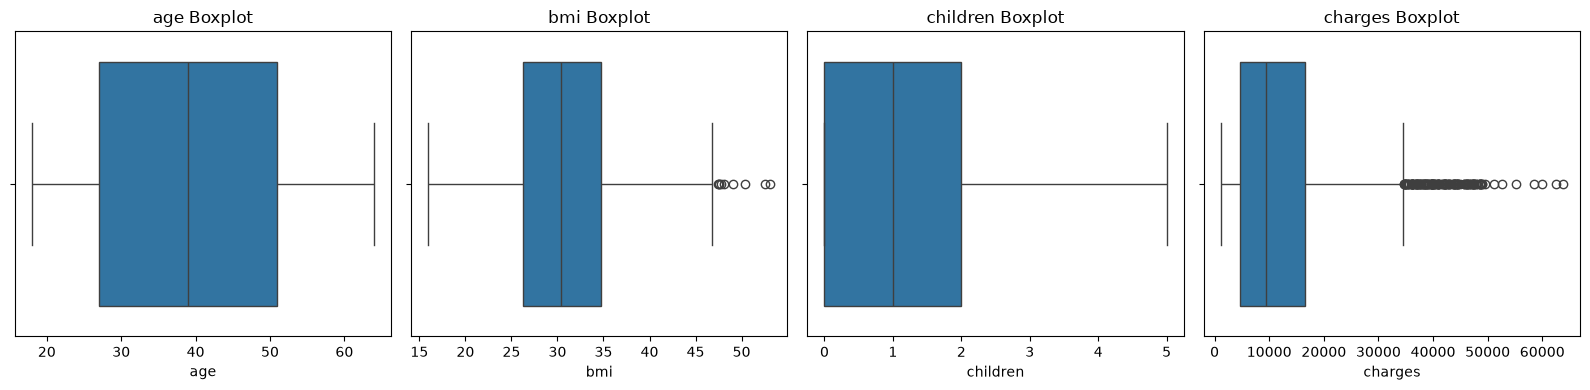

In [25]:
plot_boxplots(df, num_cols)

In [36]:
def handle_outliers_IQR(df: pd.DataFrame, num_cols) -> pd.DataFrame:
    df_clean = df.copy()
    
    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_fence = Q1 - 1.5 * IQR
        upper_fence = Q3 + 1.5 * IQR
        
        df.loc[df[col] < lower_fence, col] = lower_fence
        df.loc[df[col] > upper_fence, col] = upper_fence
        
    return df

In [37]:
df_clean= handle_outliers_IQR(df,num_cols)

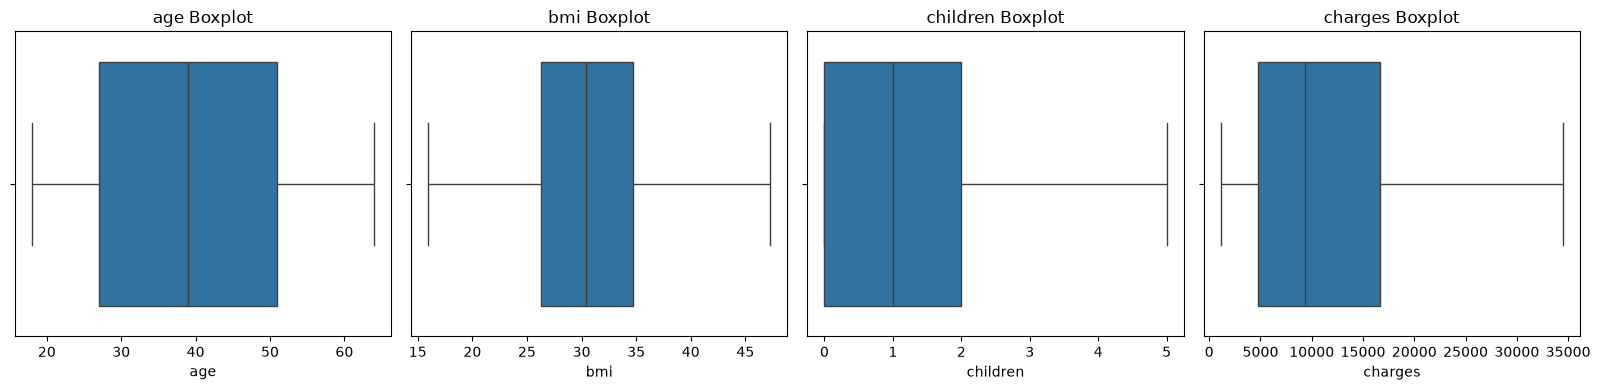

In [38]:
plot_boxplots(df, num_cols)

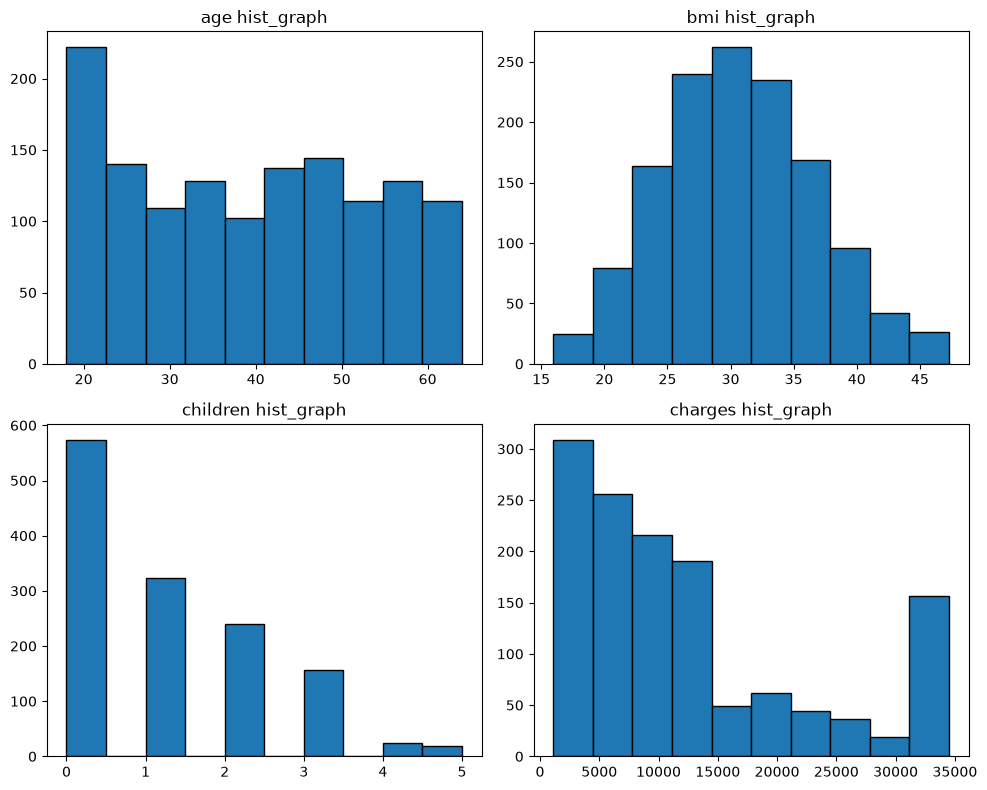

In [ ]:

plt.figure(figsize=(10, 8))

for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i + 1)
    plt.hist(df[col], edgecolor="black")
    plt.title(f"{col} hist_graph")

plt.tight_layout()
plt.show()

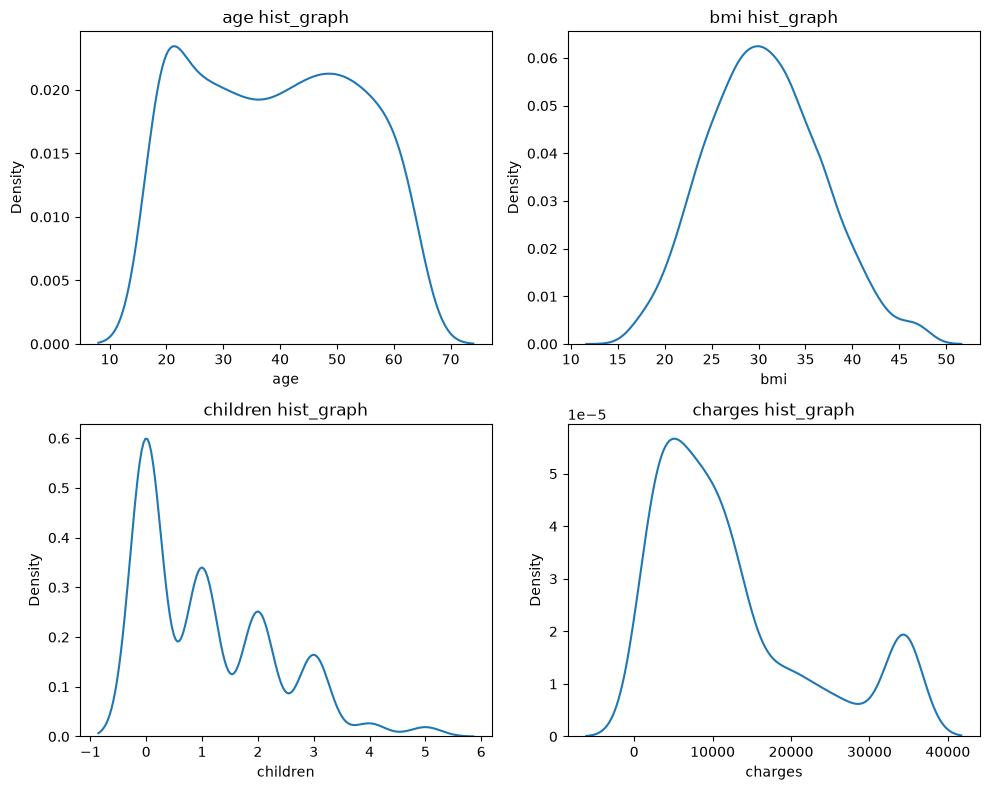

In [43]:
num_cols = df.select_dtypes('number').columns
plt.figure(figsize=(10,8))
for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i+1)
    sns.kdeplot(df[col])
    plt.title(f"{col} hist_graph")
plt.tight_layout()
plt.show()

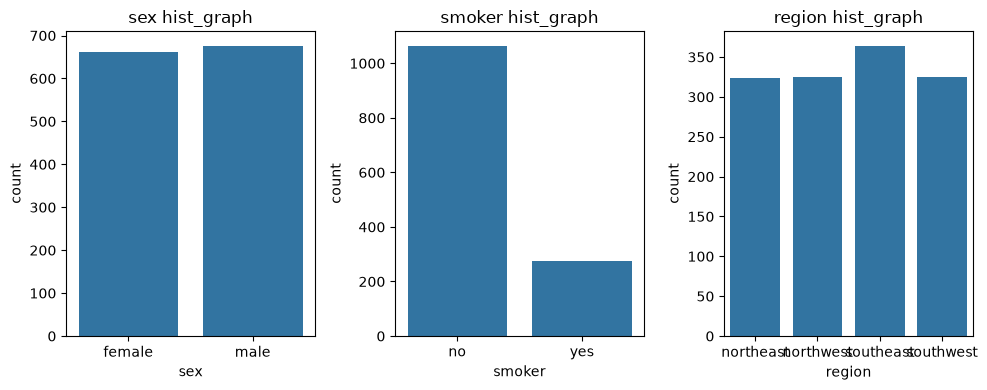

In [49]:
plt.figure(figsize=(10,4))
for i, col in enumerate(columns_cat):
    plt.subplot(1, 3, i+1)
    sns.countplot(x = col, data = df)
    plt.title(f"{col} hist_graph")
plt.tight_layout()
plt.show()

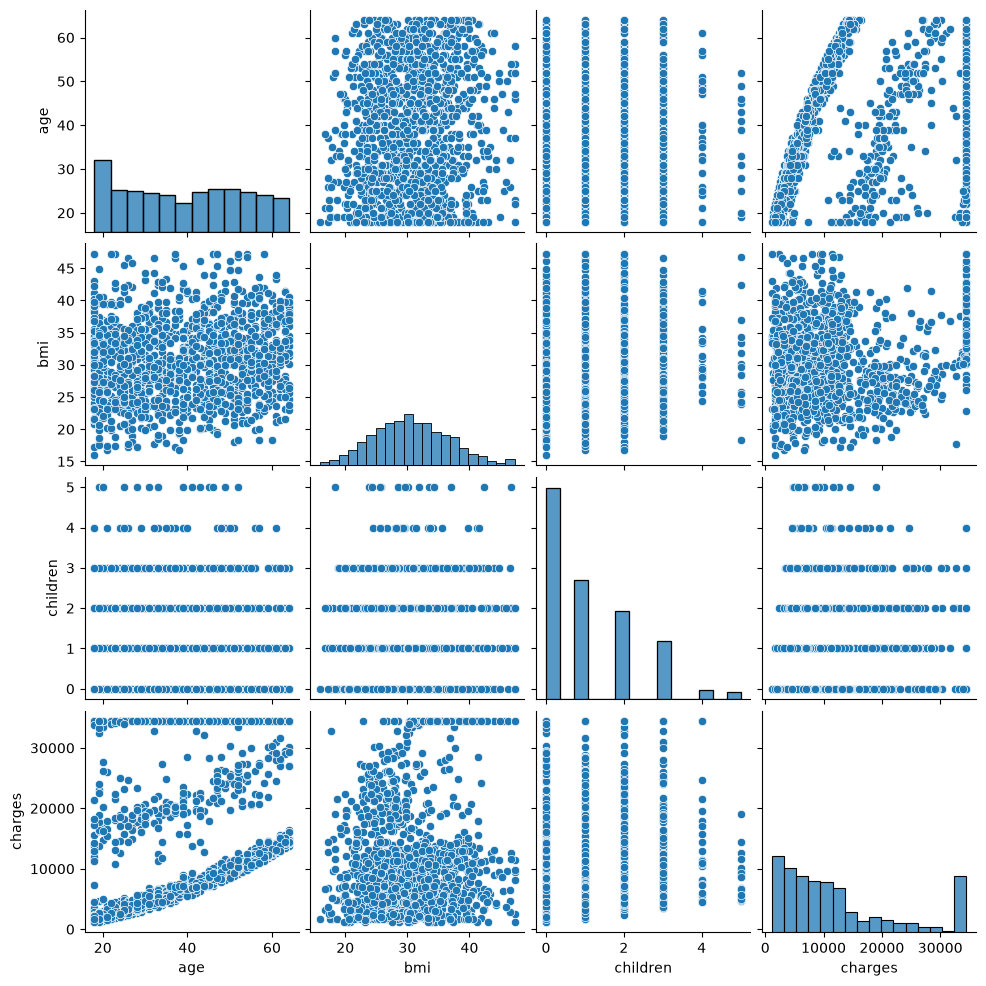

In [50]:
sns.pairplot(df)

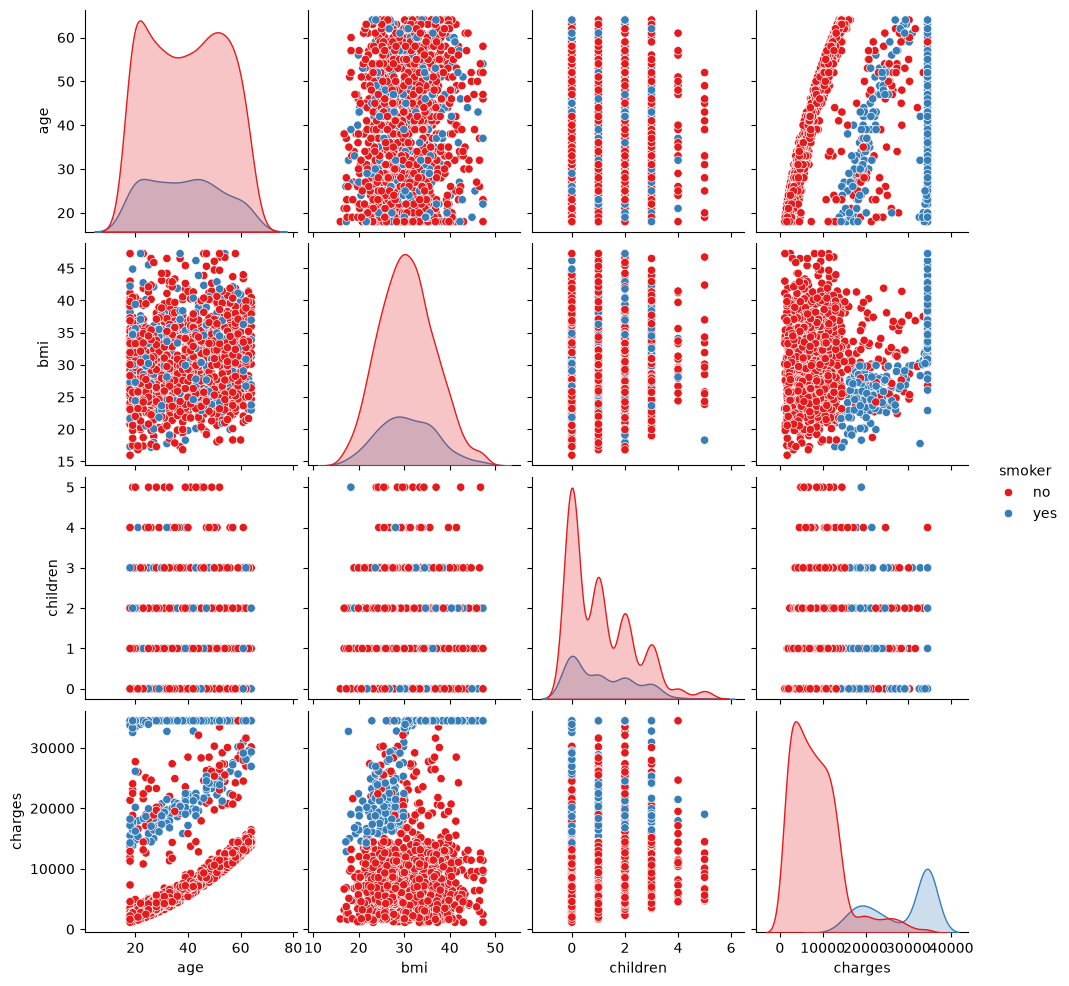

In [51]:
sns.pairplot(df, hue="smoker", palette="Set1")
plt.show()

In [ ]:
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "notebook_connected"

fig = px.pie(
    df,
    names="sex",
    title="<b>Sex Distribution</b>",
    color_discrete_sequence=px.colors.qualitative.Pastel,
    hole=0.7,
)

fig.update_layout(
    annotations=[
        dict(text="Sex", font_size=20, x=0.5, y=0.5, showarrow=False)
    ]
)

fig.show(renderer="browser")